### Required Modules

In [1]:
import os
import sys
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor

Local scripts:

In [2]:
project_root = os.path.abspath("..")
sys.path.append(project_root)

from models.custom_regression_tree import CustomRegressionTree as CRTree
from models.custom_random_forest import CustomRandomForest as CRForest

### Global Variables

In [3]:
# FILEPATH = os.path.join("..", "data", "Maternal_Health_Risk.csv")
FILEPATH = os.path.join("..", "data", "Car_Price_Prediction.csv")
SEED = 42
# LABEL = "RiskLevel"
LABEL = "Price"

### Utility Methods

In [4]:
def model_version(name: str, params: dict) -> str:
    """Join model name with parameters"""
    parameters = str(params).replace(":", "=").replace(" ", "").replace("'", "")
    return name + '@' + parameters


def get_scores(label: np.array, prediction: np.array) -> dict:
    """Calculate model prediction scores"""
    rmse = np.sqrt(np.mean((prediction - label) ** 2))
    mape = np.mean(np.abs((label - prediction) / label)) * 100
    return {"RMSE": rmse, "MAPE": mape}

### Data Ingestion

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


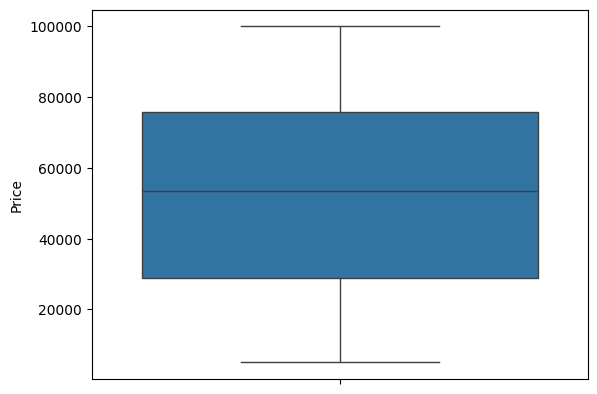

In [12]:
data = pd.read_csv(FILEPATH)

sns.boxplot(data[LABEL])

data.head()

## Modeling

Train and test (holdout) split:

In [6]:
df_trn, df_tst = train_test_split(
    data,
    train_size=0.7,
    shuffle=True,
    random_state=SEED)

df_trn.shape, df_tst.shape

((1750, 10), (750, 10))

### Define Hyperparameters

In [29]:
max_depth = [3, 6, 12, 24]
min_samples_split = [2, 4, 8]
n_trees = [50]
alpha = [1.0, 10.0, 100.0, 1000.0, 10000.0]


tree_param_grid = [
    { "max_depth": mxd, "min_samples_split": mss }
    for mxd in max_depth
    for mss in min_samples_split
]

sklearn_tree_param_grid = [
    {
        "max_depth": mxd,
        "min_samples_split": mss,
        "random_state": SEED
    }
    for mxd in max_depth
    for mss in min_samples_split
]

forest_param_grid = [
    { "n_trees": ntr, "max_depth": mxd, "min_samples_split": mss }
    for ntr in n_trees
    for mxd in max_depth
    for mss in min_samples_split
]

sklearn_forest_param_grid = [
    {
        "max_depth": mxd,
        "min_samples_split": mss,
        "n_estimators": 50,
        "random_state": SEED
    }
    for mxd in max_depth
    for mss in min_samples_split
]

sklearn_linear_param_grid = [
    {
        "alpha": alp,
        "max_iter": 10000,
        "random_state": SEED
    }
    for alp in alpha
]


models_to_run = {
    "CUSTOM_REGRESSION_TREE": (CRTree, tree_param_grid),
    "SKLEARN_REGRESSION_TREE": (DecisionTreeRegressor, sklearn_tree_param_grid),
    "CUSTOM_RANDOM_FOREST": (CRForest, forest_param_grid),
    "SKLEARN_RANDOM_FOREST": (RandomForestRegressor, sklearn_forest_param_grid),
    "SKLEARN_LINEAR_REGRESSOR": (Lasso, sklearn_linear_param_grid)}

### Cross-Validation

In [30]:
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

features = [c for c in df_trn if c != LABEL]
numeric_features = df_trn[features].select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in features if c not in numeric_features]

model_scores = {}
for indexes_trn, indexes_vln in kf.split(df_trn):

    X_trn_raw = df_trn.iloc[indexes_trn][features]
    X_vln_raw = df_trn.iloc[indexes_vln][features]

    y = df_trn[LABEL].values
    y_trn, y_vln = y[indexes_trn], y[indexes_vln]

    # Pre-processing
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_features),
            (
                "num",
                StandardScaler(),
                numeric_features)])

    X_trn = preprocessor.fit_transform(X_trn_raw)
    X_vln = preprocessor.fit_transform(X_vln_raw)


    for name in models_to_run:
        regressor, parameter_grid = models_to_run[name]
        for params in parameter_grid:

            version = model_version(name, params)
            if version not in model_scores.keys():
                model_scores[version] = {"RMSE": [], "MAPE": []}

            model = regressor(**params)
            model.fit(X_trn, y_trn)
            prediction = model.predict(X_vln)

            metrics = get_scores(y_vln, prediction)
            model_scores[version]["RMSE"].append(metrics["RMSE"])
            model_scores[version]["MAPE"].append(metrics["MAPE"])

### Generate Plots

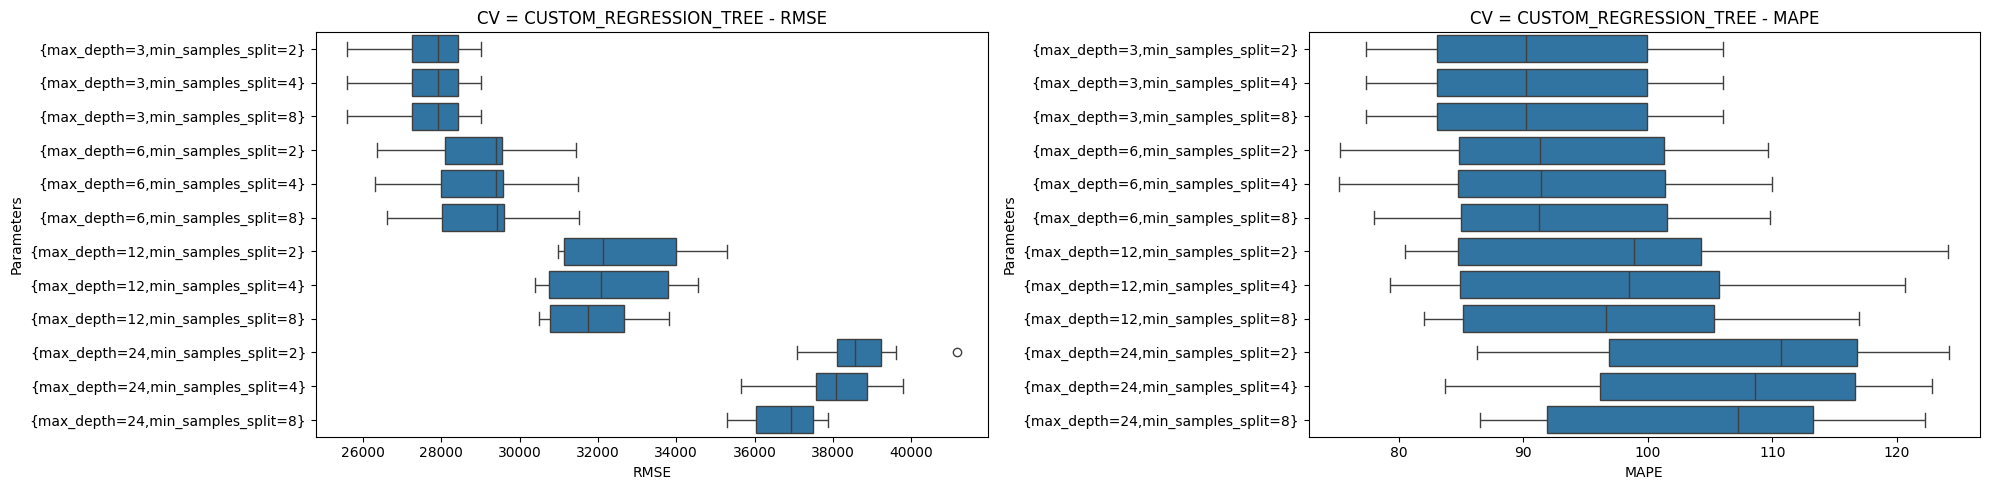

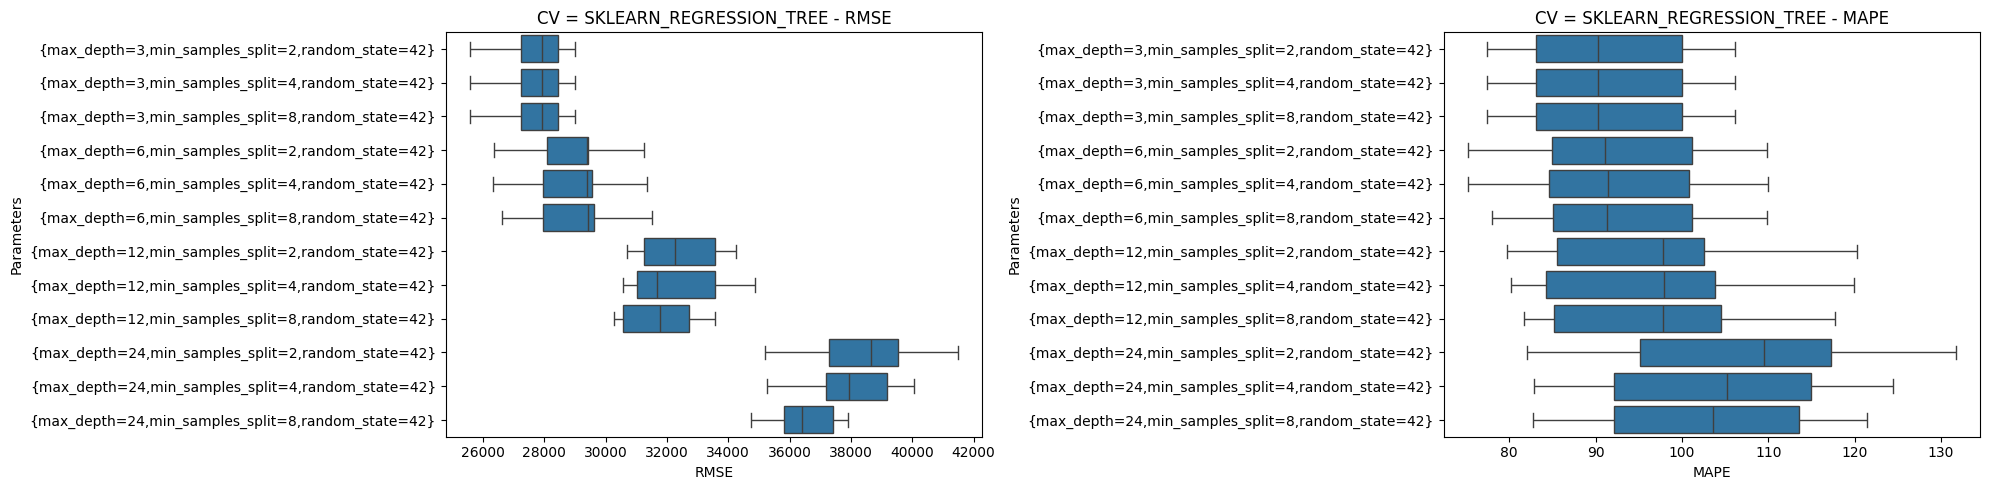

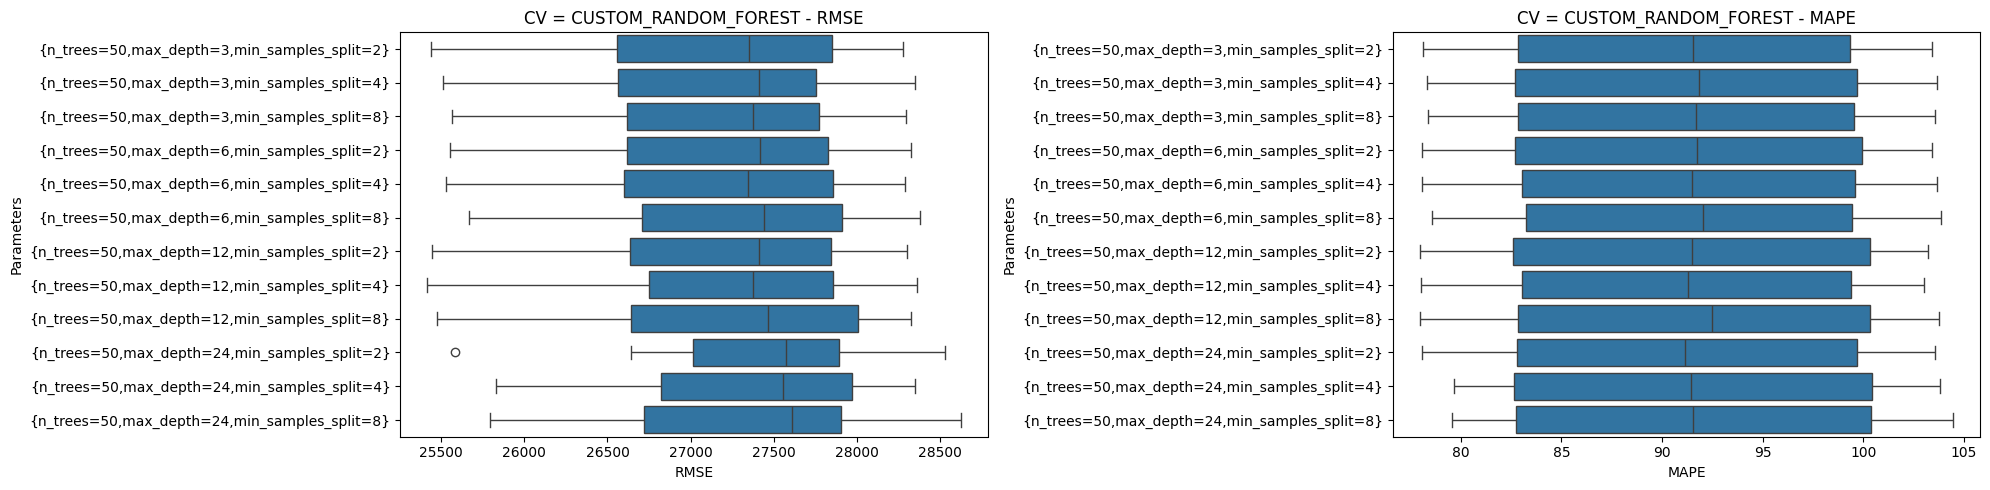

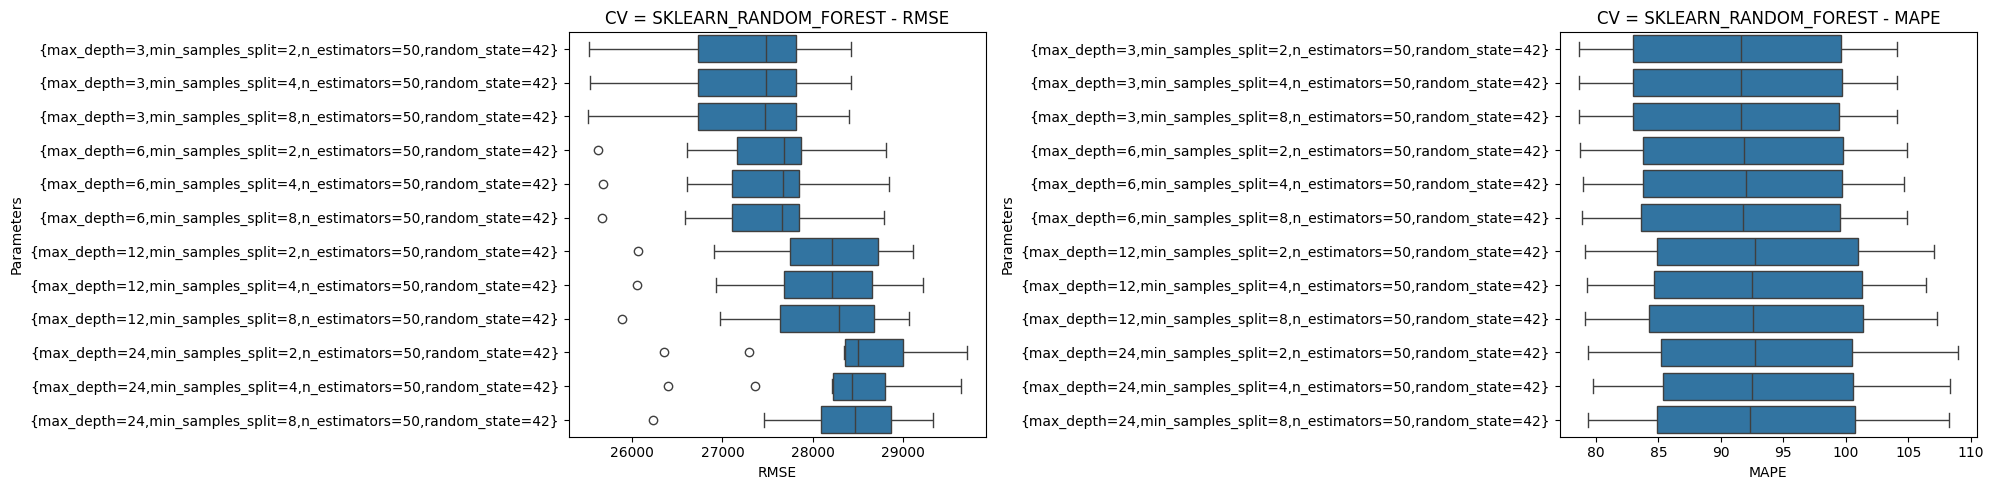

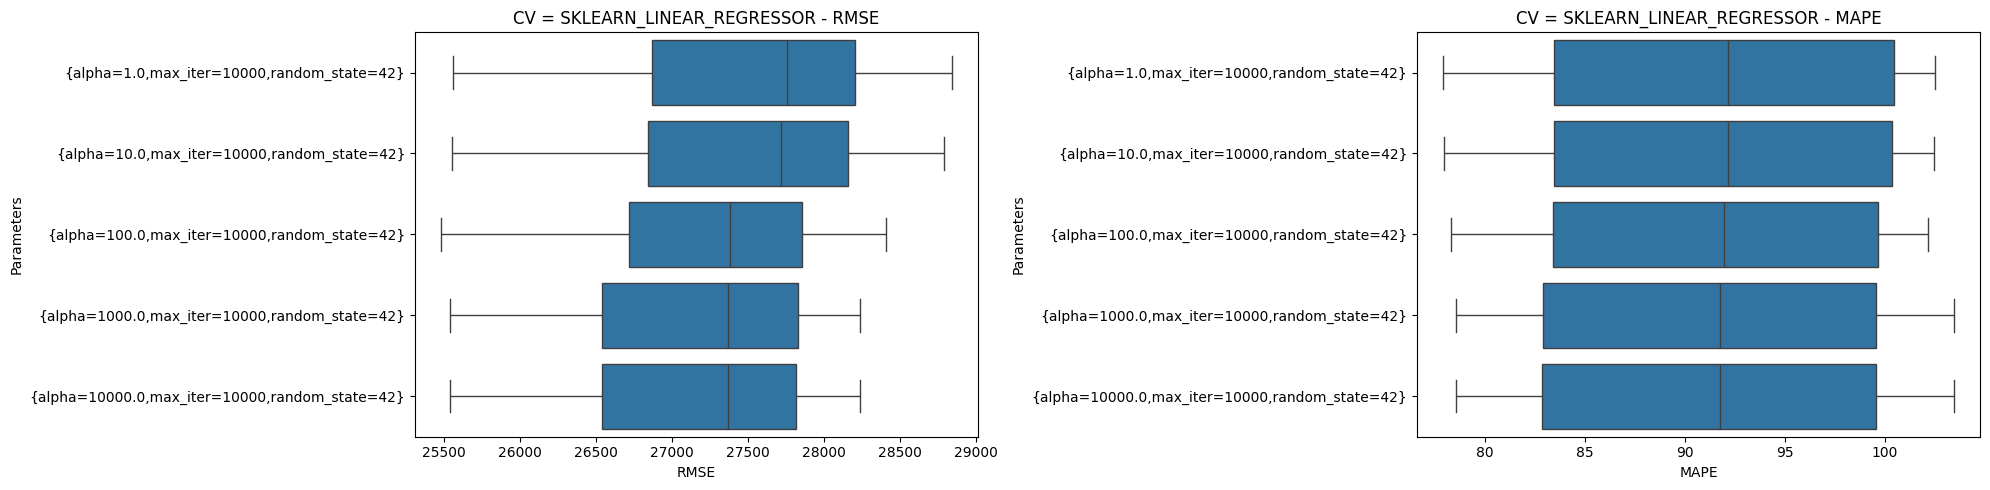

In [31]:
results = []

for name in models_to_run:
    model_data = []

    for version, scores in model_scores.items():
        if name in version:

            _, params_str = version.split("@")

            for metric, score in scores.items():
                part = pd.DataFrame([
                    {
                        "MODEL": name,
                        "PARAMS": params_str,
                        "METRIC": metric,
                        "FOLD": fold,
                        "VALUES": values}
                    for fold, values in enumerate(score)])
                params_dict = part["PARAMS"].apply(
                    lambda s: dict(re.findall(r"([^={},\s]+)=([^={},\s]+)", s))).copy()
                part = part.join(params_dict.apply(pd.Series))
                model_data.append(part)

    detail = pd.concat(model_data)
    
    if "max_depth" in detail.columns:
        detail["max_depth"] = detail["max_depth"].astype(int)

    if "min_samples_split" in detail.columns:
        detail["min_samples_split"] = detail["min_samples_split"].astype(int)

    if "alpha" in detail.columns:
        detail["alpha"] = detail["alpha"].astype(float)

    metrics = detail["METRIC"].unique()
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))

    for i, metric in enumerate(metrics):
        detail_metric = detail[detail["METRIC"] == metric]
        sns.boxplot(data=detail_metric, x="VALUES", y="PARAMS", ax=axes[i])
        axes[i].set_ylabel("Parameters")
        axes[i].set_xlabel(metric)
        axes[i].title.set_text(f"CV = {name} - {metric}")
    plt.tight_layout()

    results.append(
        detail.groupby(
            ["MODEL", "PARAMS", "METRIC"])["VALUES"].agg(
                ["mean", "min", "max", "std"]).copy())

by [Manuel Velarde](mailto:manuel@velarde.me)